In [6]:
from langgraph.graph import StateGraph,START,END 
from typing import TypedDict

In [ ]:
class state(TypedDict):
    runs:int
    balls:int 
    fours:int
    sixes:int

    sr:float #strike_rate
    bpb:float  #boundry per ball
    boundry_percentage:float 
    summary:str


In [8]:
def sr_calculator(state:state):
    sr=(state['runs']/state['balls'])*100
    return {'sr':sr}


In [9]:
def bpb_calculator(state:state):
    bpb=state['balls']/(state['fours']+state['sixes'])
    return {'bpb':bpb}

In [25]:
def bp_calculator(state:state):
    bp=(((state['fours']*4)+(state['sixes']*6))/state['runs'])*100
    return {'boundry_percentage':bp}

In [16]:
def summary(state:state):
    summary_text=f"""the sr is {state['sr']}
    the bpb is{state['bpb']}
    and the boundry_percentage is {state['boundry_percentage']} """
    return {'summary':summary_text}


In [26]:
graph=StateGraph(state)

# defining_nodes 

graph.add_node("sr_calculator",sr_calculator)
graph.add_node("bpb_calculator",bpb_calculator)
graph.add_node("bp_calculator",bp_calculator)
graph.add_node('summary',summary)

#defining_edge

graph.add_edge(START,'sr_calculator')
graph.add_edge(START,'bpb_calculator')
graph.add_edge(START,'bp_calculator')

graph.add_edge('sr_calculator','summary')
graph.add_edge('bpb_calculator','summary')
graph.add_edge('bp_calculator','summary')

graph.add_edge('summary',END)

workflow=graph.compile()

intial_state={'runs':100,'balls':50,'fours':4,'sixes':6}
result=workflow.invoke(intial_state)
print(result)




{'runs': 100, 'balls': 50, 'fours': 4, 'sixes': 6, 'sr': 200.0, 'bpb': 5.0, 'boundry_percentage': 52.0, 'summary': 'the sr is 200.0\n    the bpb is5.0\n    and the boundry_percentage is 52.0 '}


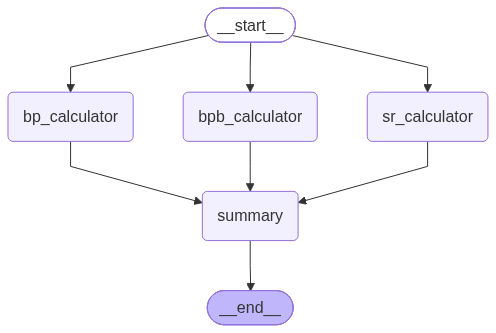

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())